# RAG With Hatstack 2.0

**Author:** Shinin Varongchayakul

**Date:** 09 Jul 2026

Dataset from: https://www.kaggle.com/datasets/hgultekin/bbcnewsarchive

## 1. Indexing Pipeline

### 1.1 Create Documents

#### 1.1.1 Load File

In [44]:
# Import package
import pandas as pd

# Load CSV
df = pd.read_csv("bbc-news-data.csv", sep="\t")

In [69]:
# Inspect first 5 rows
df.head()

,category,filename,title,content
0,business,001.txt,Ad sales boost Time Warner profit,Quarterly profits at US media giant TimeWarne...
1,business,002.txt,Dollar gains on Greenspan speech,The dollar has hit its highest level against ...
2,business,003.txt,Yukos unit buyer faces loan claim,The owners of embattled Russian oil giant Yuk...
3,business,004.txt,High fuel prices hit BA's profits,British Airways has blamed high fuel prices f...
4,business,005.txt,Pernod takeover talk lifts Domecq,Shares in UK drinks and food firm Allied Dome...


#### 1.1.2 Convert to Document object

In [46]:
# Import package
from haystack import Document

# Instantiate collector
docs = []

# Loop through records
for row in df.itertuples():
    doc = Document(
        content=row.content,
        meta={
            "title": row.title,
            "category": row.category,
            "filename": row.filename
        }
    )
    docs.append(doc)

In [ ]:
# Inspect one document
docs[0]

Document(id=7fe87ca8e57420adb9ed47866809d38424003dd43b4eefdf6b1a400eb3709677, content: ' Quarterly profits at US media giant TimeWarner jumped 76% to $1.13bn (£600m) for the three months t...', meta: {'title': 'Ad sales boost Time Warner profit', 'category': 'business', 'filename': '001.txt'})

### 1.2 Create Splitter

In [48]:
# Import package
from haystack.components.preprocessors import RecursiveDocumentSplitter

# Create splitter
splitter = RecursiveDocumentSplitter(
    split_length=180,
    split_overlap=30,
    split_unit="word",
    separators=[
        "\n\n",
        "sentence",
        "\n",
        " ",
    ]
)

### 1.3 Create Embedder

In [ ]:
# Import package
from haystack_integrations.components.embedders.sentence_transformers import (
    SentenceTransformersDocumentEmbedder
)

# Create document embedder
document_embedder = SentenceTransformersDocumentEmbedder(
    model="sentence-transformers/all-MiniLM-L6-v2",
    meta_fields_to_embed=["title"],
)

### 1.4 Create Vector Store

In [50]:
# Import package
from haystack.document_stores.in_memory import InMemoryDocumentStore

# Create vector store
vector_store = InMemoryDocumentStore(
    embedding_similarity_function="cosine"
)

### 1.5 Create Document Writer

In [51]:
# Import package
from haystack.components.writers import DocumentWriter

# Create document writer
document_writer = DocumentWriter(
    document_store=vector_store
)

### 1.6 Create Indexing Pipeline

In [52]:
# Import package
from haystack import Pipeline

# Instantiate pipeline
indexing_pipeline = Pipeline()

In [53]:
# Add components
indexing_pipeline.add_component("splitter", splitter)
indexing_pipeline.add_component("embedder", document_embedder)
indexing_pipeline.add_component("writer", document_writer)

In [54]:
# Connect components
indexing_pipeline.connect("splitter.documents", "embedder.documents")
indexing_pipeline.connect("embedder.documents", "writer.documents")

🚅 Components
  - splitter: RecursiveDocumentSplitter
  - embedder: SentenceTransformersDocumentEmbedder
  - writer: DocumentWriter
🛤️ Connections
  - splitter.documents -> embedder.documents (list[Document])
  - embedder.documents -> writer.documents (list[Document])

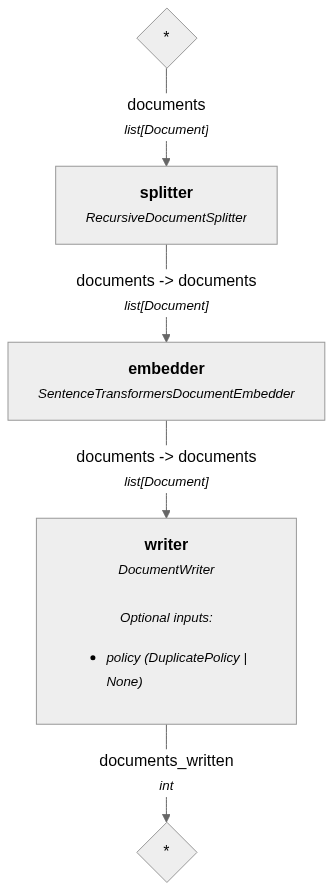

In [70]:
# Show pipeline
indexing_pipeline.show()

### 1.7 Run Indexing Pipeline

In [55]:
# Run indexing pipeline
indexing_result = indexing_pipeline.run(
    {
        "splitter": {
            "documents": docs
        }
    }
)

Batches:   0%|          | 0/225 [00:00<?, ?it/s]

In [56]:
# Check result
print(indexing_result)

{'writer': {'documents_written': 7182}}


## 2. Querying Pipeline

### 2.1 Create Query Embedder

In [57]:
# Import package
from haystack_integrations.components.embedders.sentence_transformers import (
    SentenceTransformersTextEmbedder
)

# Create question embedder
question_embedder = SentenceTransformersTextEmbedder(
    model="sentence-transformers/all-MiniLM-L6-v2"
)

### 2.2 Create Retriever

In [58]:
# Import package
from haystack.components.retrievers.in_memory import InMemoryEmbeddingRetriever

# Create retriever
retriever = InMemoryEmbeddingRetriever(
    document_store=vector_store,
    top_k=5
)

### 2.3 Create Prompt Builder

In [59]:
# Set system prompt
system_prompt = """
You are a helpful assistant for a historical BBC News Archive.

Answer only from the retrieved BBC article passages.

Rules:
- Do not use outside knowledge.
- Do not invent facts that are not supported by the passages.
- The archive is historical, so do not present its content as current news.
- Cite factual claims using source labels such as [1] or [2].
- If the retrieved passages do not contain enough evidence, say that clearly.
"""

# Set user prompt
user_prompt = """
Question:
{{ question }}

Retrieved BBC archive passages:

{% for doc in docs %}
[{{ loop.index }}]

Title: {{ doc.meta["title"] }}
Category: {{ doc.meta["category"] }}
Filename: {{ doc.meta["filename"] }}

Passage:
{{ doc.content }}

{% endfor %}

Write a concise answer using only the retrieved passages.
"""

In [60]:
# Import packages
from haystack.components.builders import ChatPromptBuilder
from haystack.dataclasses import ChatMessage

# Create prompt builder
prompt_builder = ChatPromptBuilder(
    template=[
        ChatMessage.from_system(system_prompt.strip()),
        ChatMessage.from_user(user_prompt.strip())
    ],
    required_variables=["question", "docs"],
)

### 2.4 Create Response Generator

In [61]:
# Import packages
import os
from pathlib import Path
from dotenv import load_dotenv

# Get current working directory
CURRENT_DIR = Path.cwd()

# Move up to project root
ROOT_DIR = CURRENT_DIR.parents[1]

# Define path to .env
ENV_PATH = ROOT_DIR / ".env"

# Load .env content
load_dotenv(dotenv_path=ENV_PATH)

# Get API key
GEMINI_API_KEY = os.getenv("GEMINI_API_KEY")

In [ ]:
# Import packages
from haystack.utils import Secret
from haystack_integrations.components.generators.google_genai import (
    GoogleGenAIChatGenerator
)

# Create generator
generator = GoogleGenAIChatGenerator(
    model="gemini-2.5-flash",
    api_key=Secret.from_token(GEMINI_API_KEY),
    generation_kwargs={
        "temperature": 0.2
    }
)

### 2.5 Create Querying Pipeline

In [63]:
# Import package
from haystack import Pipeline

# Instantiate pipeline
querying_pipeline = Pipeline()

In [64]:
# Add components
querying_pipeline.add_component("question_embedder", question_embedder)
querying_pipeline.add_component("retriever", retriever)
querying_pipeline.add_component("prompt_builder", prompt_builder)
querying_pipeline.add_component("generator", generator)

In [65]:
# Connect components
querying_pipeline.connect("question_embedder.embedding", "retriever.query_embedding")
querying_pipeline.connect("retriever.documents", "prompt_builder.docs")
querying_pipeline.connect("prompt_builder.prompt", "generator.messages")

🚅 Components
  - question_embedder: SentenceTransformersTextEmbedder
  - retriever: InMemoryEmbeddingRetriever
  - prompt_builder: ChatPromptBuilder
  - generator: GoogleGenAIChatGenerator
🛤️ Connections
  - question_embedder.embedding -> retriever.query_embedding (list[float])
  - retriever.documents -> prompt_builder.docs (list[Document])
  - prompt_builder.prompt -> generator.messages (list[ChatMessage])

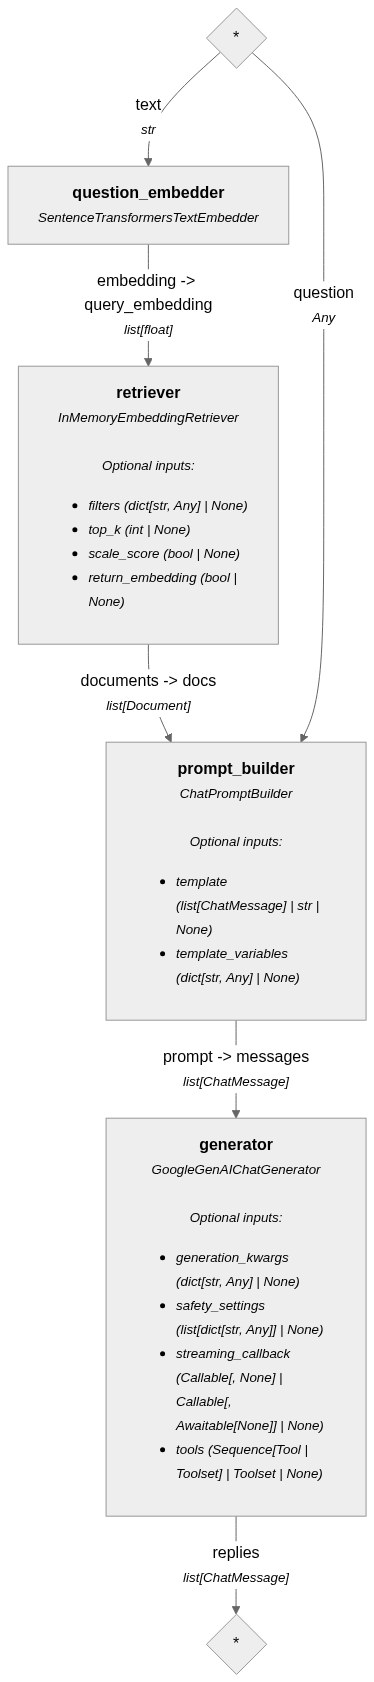

In [71]:
# Show pipeline
querying_pipeline.show()

### 2.6 Run Querying Pipeline

In [66]:
# Create function
def run_query(query: str):

    # Run pipeline
    result = querying_pipeline.run(
        {
            "question_embedder": {
                "text": query
            },
            "prompt_builder": {
                "question": query
            }
        }
    )

    # Return result
    return result["generator"]["replies"][0].text

In [67]:
# Set question
my_question = "What concerns did users raise about Google’s AutoLink feature?"

# Run query
query_result = run_query(query=my_question)

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

In [68]:
# Print result
print(query_result)

Users raised several concerns about Google's AutoLink feature:
*   It directs people to pre-selected commercial websites [1].
*   Some users were concerned that Google's dominant market position could give a competitive advantage to firms like Amazon [1].
*   The feature creates links based on information in a webpage without the publisher's permission [1]. This could lead to online libraries directing users to Amazon.com against their will, or websites with paid advertising inadvertently directing users to rival services [4].
*   Some users suggested it would only be fair if websites had to sign up to allow the feature or if they received revenue for "click throughs" to commercial sites [2].
*   Concerns were also raised about user choice, transparency regarding how much Google is paid, and the ability for users to substitute their own preferred companies for those chosen by Google [3].
*   An objection would arise if users were forced or "tricked" into using the service [3].
